In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy import optimize
import sympy as sp

 - https://stackoverflow.com/questions/75849031/solving-multiple-solution-equation-in-python/79842098#79842098
 - https://www.perplexity.ai/search/how-to-count-how-many-root-the-VQiA3p93SQC1wB_fOUr_tQ
 - https://www.wolframalpha.com/input?i=solve+tan%284+*+x%29+%3D+-+3.1*sin%28x%29+%2F+%281+%2B+3.1*cos%28x%29%29+for+x
 - https://www.wolframalpha.com/input?i=solve+tan%28M+*+x%29+%3D+-+D*sin%28x%29+%2F+%281+%2B+D*cos%28x%29%29+for+x+and+M+%3E+0%2C+D+%3E+0
 - https://www.wolframalpha.com/input?i=diff+-D+*+sin%28x%29+%2F+%281%2B+D*cos%28x%29%29+wrt+x

In [2]:
xlin = np.linspace(-4 * np.pi - 1, + 4 * np.pi + 1, 5000)

In [3]:
def g(x, M, D):
    return np.tan(M * x)

In [4]:
def hnum(x, M, D):
    return - D * np.sin(x)

In [5]:
def hdenom(x, M, D):
    return 1 + D * np.cos(x)

In [6]:
def h(x, M, D):
    return hnum(x, M, D) / hdenom(x, M, D)

In [7]:
def g_asymptotes(M, D, k=np.arange(-4, 4, 1)):
    return (1 + 2 * k) * np.pi / (2 * M)

In [8]:
def h_asymptotes(M, D, k=np.arange(-4, 4, 1)):
    if D < 1.:
        return np.array([])
    return np.hstack([
        + np.arccos(-1. / D) + 2 * np.pi * k,
        - np.arccos(-1. / D) + 2 * np.pi * k,
    ])

In [9]:
p0s = [
    {"M": 0.5, "D": 0.5},
    {"M": 0.5, "D": 1.},
    {"M": 0.5, "D": 3.},
    {"M": 0.9, "D": 0.5},
    {"M": 0.9, "D": 1.},
    {"M": 0.9, "D": 3.},
    {"M": 1., "D": 0.5},
    {"M": 1., "D": 1.},
    {"M": 1., "D": 3.},
    {"M": 2., "D": 0.5},
    {"M": 2., "D": 1.},
    {"M": 2., "D": 3.},
]

In [10]:
def truncate(y, ymax):
    z = y.copy()
    z[np.abs(z) > ymax] = np.nan
    return z

In [11]:
ymax = 10.

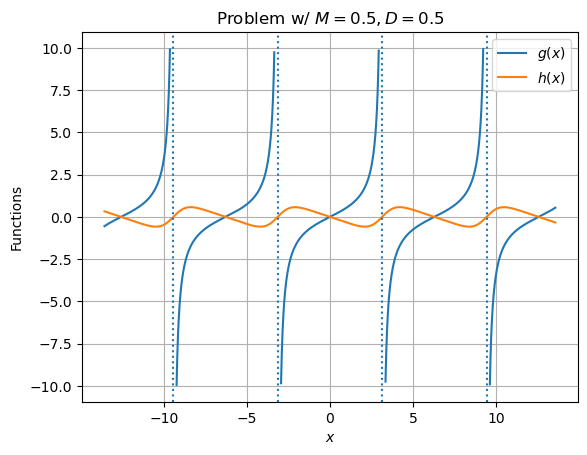

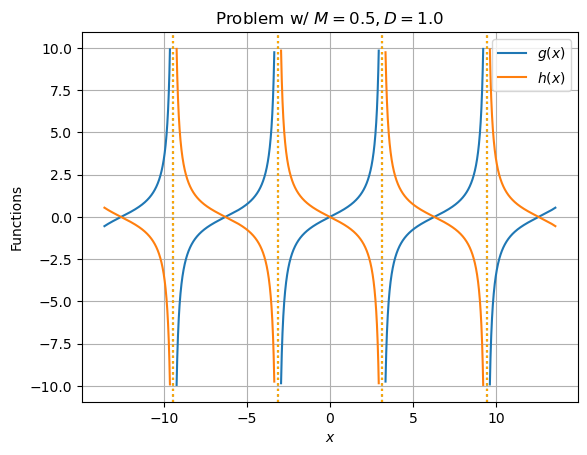

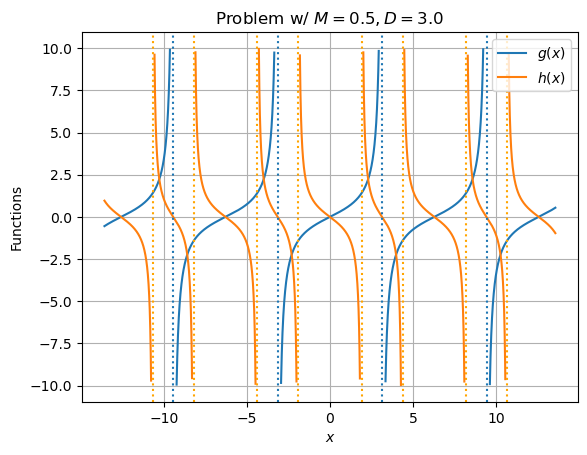

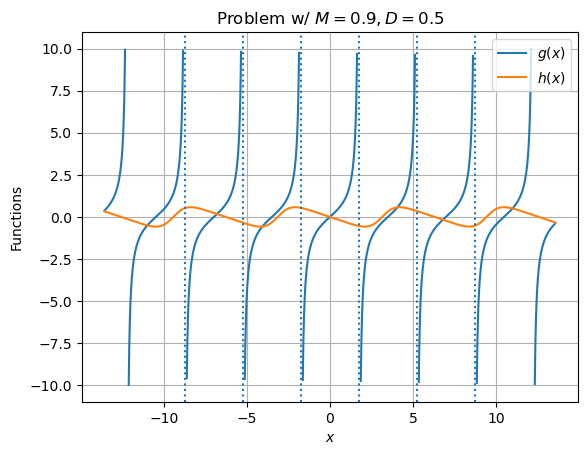

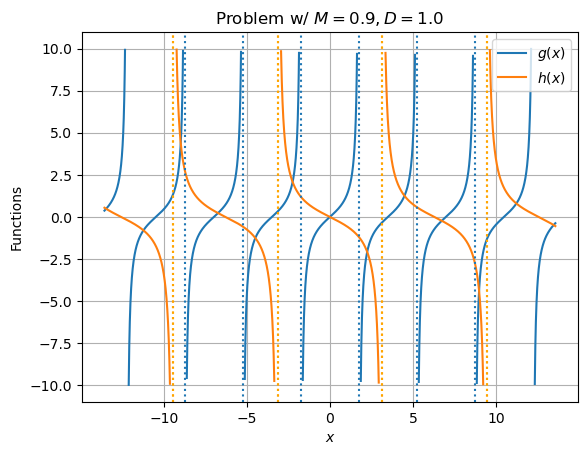

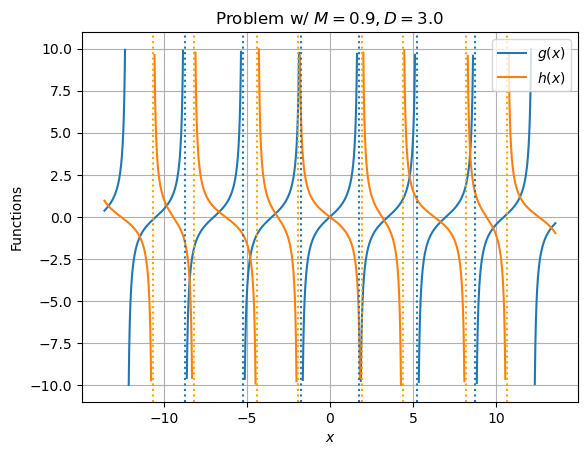

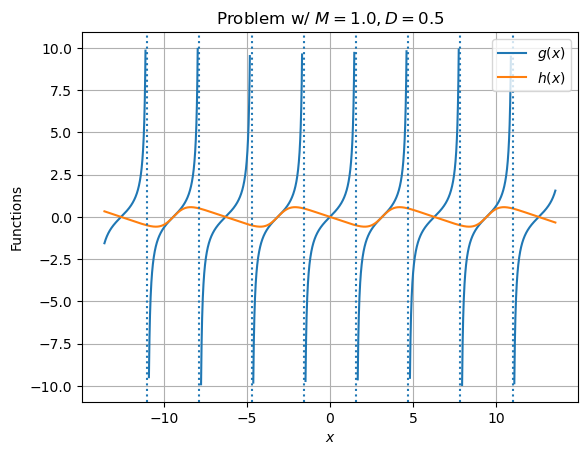

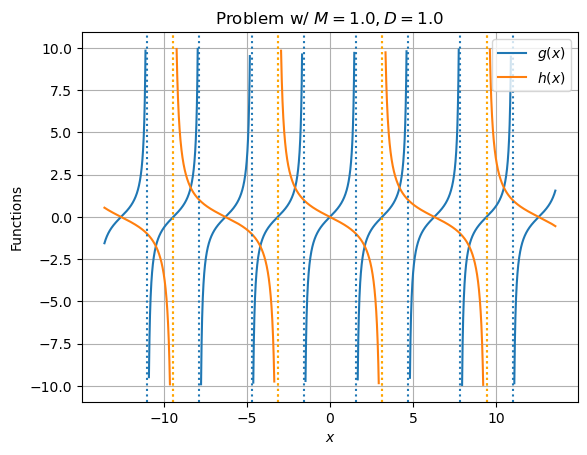

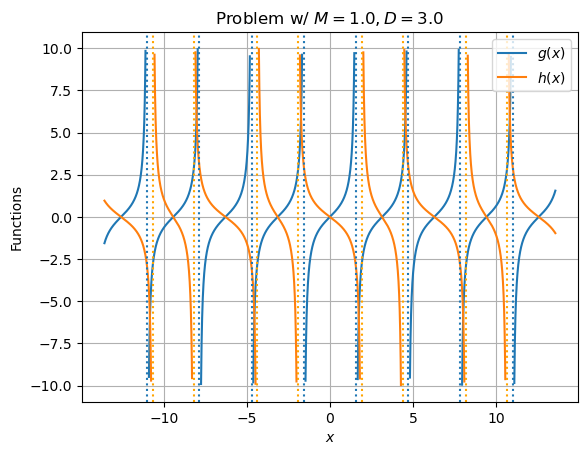

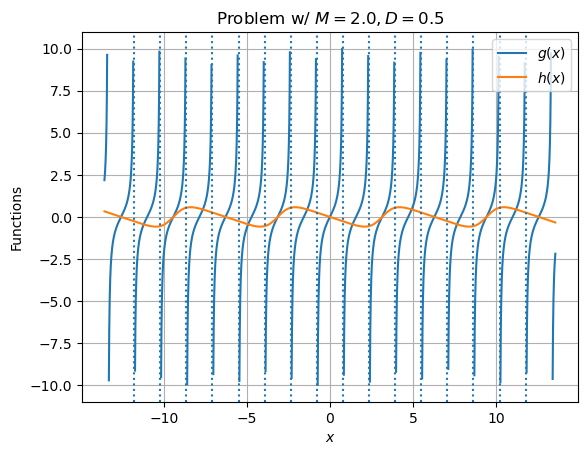

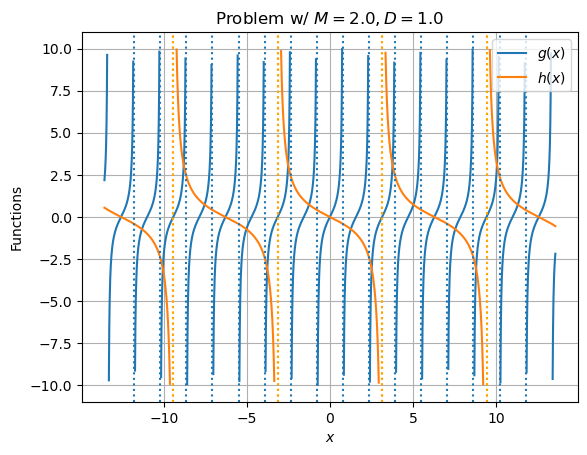

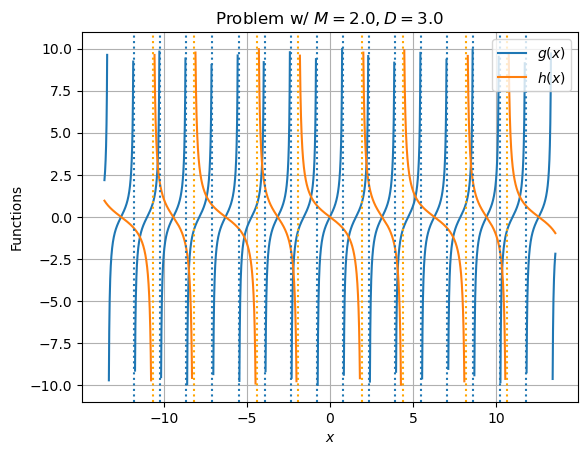

In [12]:
for p0 in p0s:

    glin = truncate(g(xlin, **p0), ymax)
    hlin = truncate(h(xlin, **p0), ymax)

    gks = np.arange(- int(4 * p0['M']), int(4 * p0['M']), 1)
    gas = g_asymptotes(**p0, k=gks)

    hks = np.arange(- int(4 * p0['D']), int(4 * p0['D']), 1)
    has = h_asymptotes(**p0, k=hks)
    has = has[(has >= xlin.min()) & (has <= xlin.max())]
    
    fig, axe = plt.subplots()
    axe.plot(xlin, glin, label="$g(x)$")
    axe.plot(xlin, hlin, label="$h(x)$")

    for ga in gas:
        axe.axvline(ga, linestyle=":")

    for ha in has:
        axe.axvline(ha, linestyle=":", color="orange")
    
    axe.set_title(f"Problem w/ $M={p0['M']}, D={p0['D']}$")
    axe.set_xlabel("$x$")
    axe.set_ylabel("Functions")
    axe.grid()
    axe.legend()
    